In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
terror = pd.read_csv(r'C:\Users\LENOVO\Downloads\globalterrorismdb_0718dist.csv\globalterrorismdb_0718dist.csv',
            encoding='latin1',
            usecols= ['iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'success', 
                      'suicide', 'attacktype1_txt', 'targtype1_txt', 'targsubtype1_txt', 'gname'])

In [4]:
terror.info()

<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   iyear             181691 non-null  int64
 1   imonth            181691 non-null  int64
 2   iday              181691 non-null  int64
 3   country_txt       181691 non-null  str  
 4   region_txt        181691 non-null  str  
 5   success           181691 non-null  int64
 6   suicide           181691 non-null  int64
 7   attacktype1_txt   181691 non-null  str  
 8   targtype1_txt     181691 non-null  str  
 9   targsubtype1_txt  171318 non-null  str  
 10  gname             181691 non-null  str  
dtypes: int64(5), str(6)
memory usage: 15.2 MB


In [5]:
rename = {'iyear':'year',
          'imonth':'month',
          'iday':'day',
          'country_txt':'country',
          'region_txt':'region',
          'attacktype1_txt':'attack_type',
          'targtype1_txt':'target',
          'targsubtype1_txt':'sub_target',
          'gname':'gang_name'}

terror.rename(columns=rename,inplace=True)

In [6]:
terror.dropna(inplace=True)

In [7]:
terror['success'] = terror['success'].astype('int8')
terror['suicide'] = terror['suicide'].astype('int8')
terror['month'] = terror['month'].astype('int8')
terror['day'] = terror['day'].astype('int8')

In [8]:
terror.info()

<class 'pandas.DataFrame'>
Index: 171318 entries, 0 to 181689
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   year         171318 non-null  int64
 1   month        171318 non-null  int8 
 2   day          171318 non-null  int8 
 3   country      171318 non-null  str  
 4   region       171318 non-null  str  
 5   success      171318 non-null  int8 
 6   suicide      171318 non-null  int8 
 7   attack_type  171318 non-null  str  
 8   target       171318 non-null  str  
 9   sub_target   171318 non-null  str  
 10  gang_name    171318 non-null  str  
dtypes: int64(1), int8(4), str(6)
memory usage: 11.1 MB


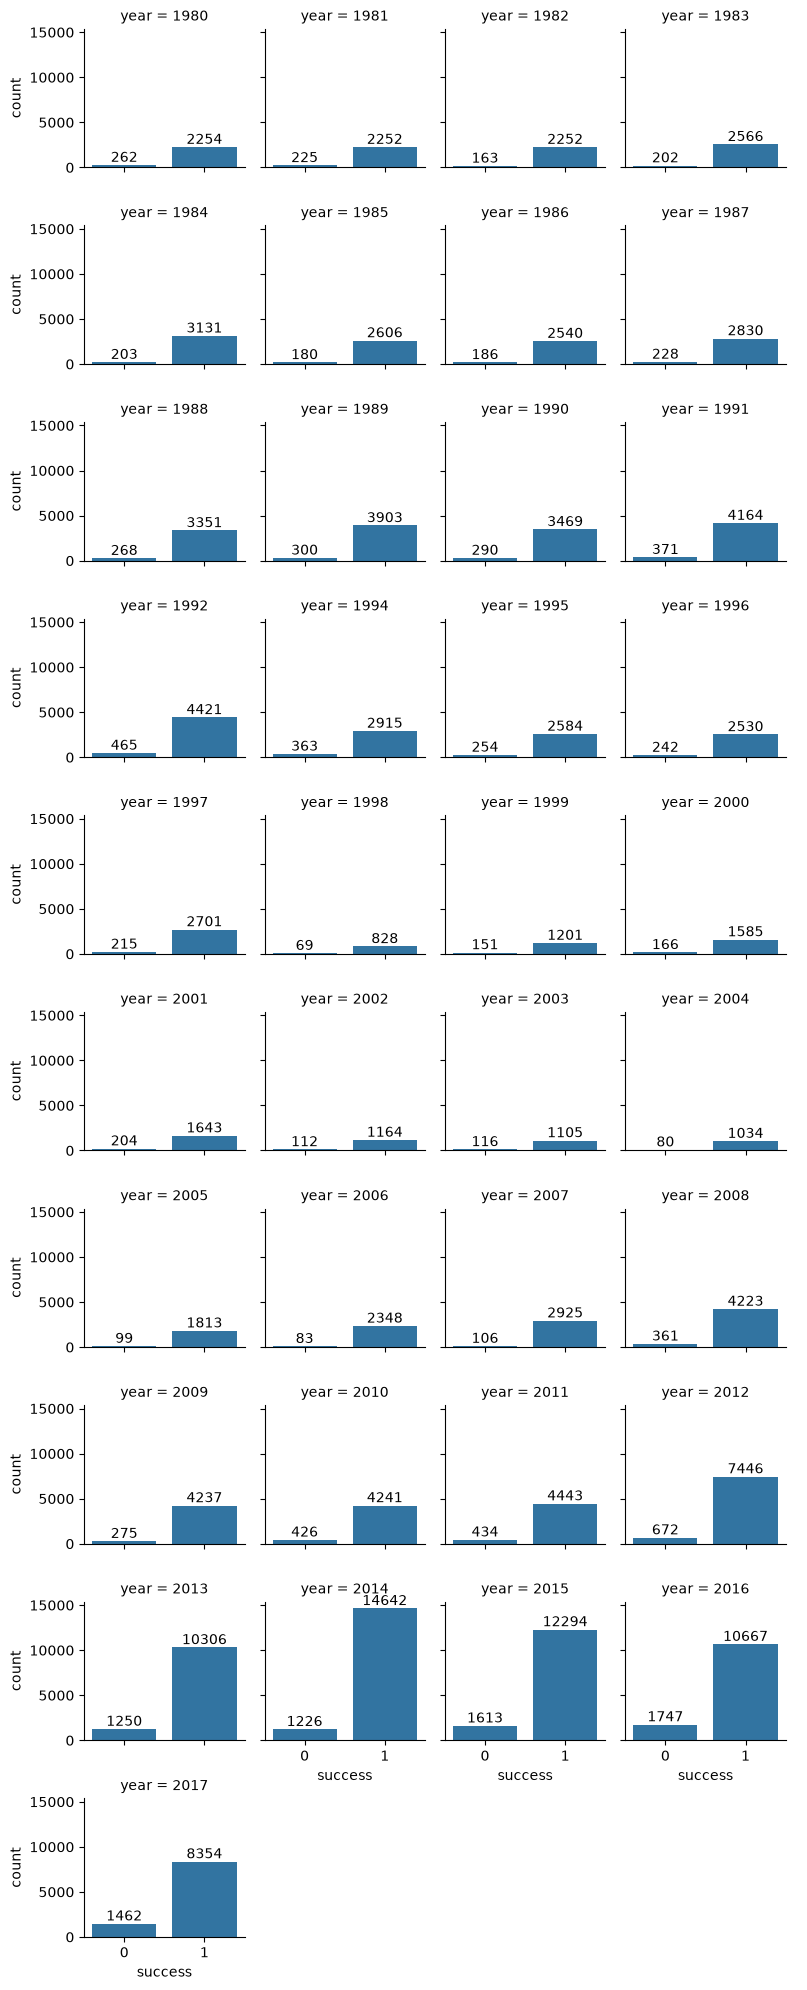

In [10]:
g = sns.catplot(kind='count' ,
            data = terror[terror['year']>= 1980], 
            x= 'success', 
            col= 'year', col_wrap=4,
            aspect= 1,
            height= 2,
            )
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

In [11]:
# g = sns.FacetGrid(terror, col='year', col_wrap=4, height=2, aspect=1)
# g.map(sns.countplot, 'success')

# for ax in g.axes.flat:
#     for container in ax.containers:
#         ax.bar_label(container)

In [12]:
top_10_victim_country = terror.groupby('country')['success'].sum().sort_values(ascending=False)[:10]

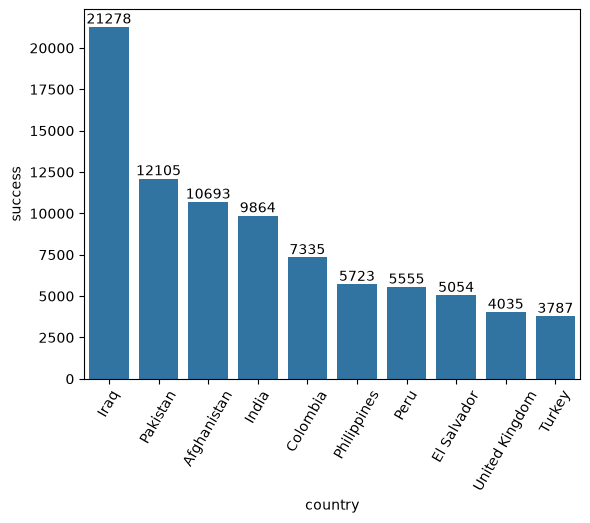

In [13]:
ax = sns.barplot(top_10_victim_country)
plt.xticks(rotation = 60)

for container in ax.containers:
    ax.bar_label(container)

In [14]:
country = terror.groupby('country')

In [15]:
iraq_attacts = country.get_group('Iraq')[['success', 'year']]
iraq_attacts

,success,year
2854,1,1975
4385,1,1976
4393,1,1976
4402,1,1976
8688,1,1979
...,...,...
181669,1,2017
181670,1,2017
181671,1,2017
181674,0,2017


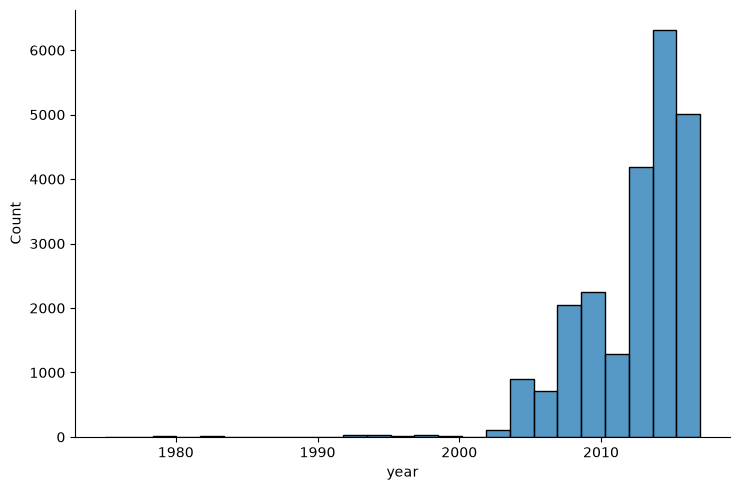

In [16]:
g = sns.displot(kind='hist', data = iraq_attacts, x = 'year', height=5, aspect= 1.5, bins = 25)


In [26]:
attack = terror.groupby('attack_type')['success'].count()
attack

attack_type
Armed Assault                          41825
Assassination                          18555
Bombing/Explosion                      80765
Facility/Infrastructure Attack          9932
Hijacking                                631
Hostage Taking (Barricade Incident)      977
Hostage Taking (Kidnapping)            10561
Unarmed Assault                          982
Unknown                                 7090
Name: success, dtype: int64

<Figure size 2000x2000 with 0 Axes>

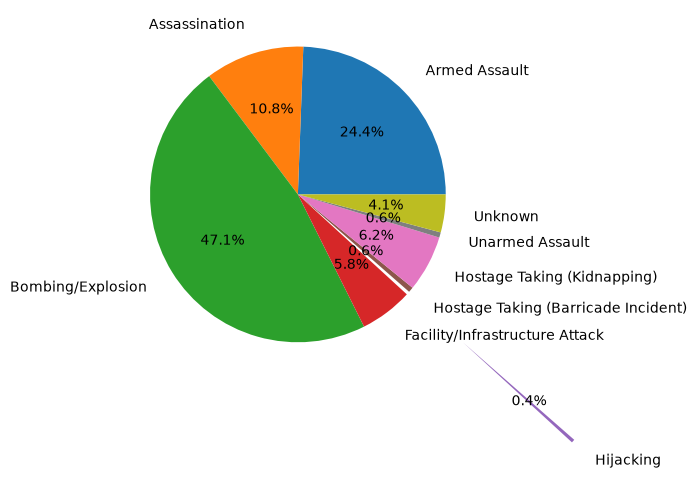

<Figure size 2000x2000 with 0 Axes>

In [59]:
plt.pie(attack, labels=attack.index, labeldistance= 1.2, explode=[0,0,0,0,1.5, 0,0,0,0], autopct='%0.1f%%')

plt.figure(figsize=(20,20))